# Notebook for pseudobulk generating

- **N** равно числу клеток данной ткани в split'е — цель ~один псевдобалк на каждую train/test-клетку для каждого K.
- Якоря для bootstrap выбираются **без возвращением** из пула (класс `Pseudobulk_Bootstrap`), поэтому все якоря уникальные.

После генерации матрицы по всем тканям и K **склеиваются по колонкам** и перемешиваются (`sample(frac=1, axis=1)`).

---

## Ожидаемые размеры

| Split | Клеток | K | Итого псевдобалков |
|-------|--------|---|---------------------|
| Train | 1847 | × 5 | **9 235** |
| Test  | 463  | × 5 | **2 315** |

Распределение train-клеток по тканям: 293T-MS (431), A549-MS (500), HELA-MS (428), K562-MS (488).

---

## Особый случай K = 1

При `K = 1` класс возвращает **сырые single-cell профили** без агрегации, с **оригинальными баркодами** в качестве имён колонок.

---

## Связь с инференсом

Пайплайн KNN (log1p-CPM → HVG → PCA → NearestNeighbors → sum counts → TPM/CPM) согласован с `predict_knn_pseudobulk()` в `preprocessor.py`, чтобы обучение и предсказание работали на одном типе объектов.

In [8]:
import pandas as pd

test_b = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/barcodes_test_split.csv', index_col=0)
train_b = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/barcodes_train_split.csv', index_col=0)
all_b = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/barcodes_combined_filtered.csv', index_col=0)

In [2]:
len(set(test_b['barcode'].tolist()))

463

In [3]:
len(set(train_b['barcode'].tolist()))

1847

In [4]:
len(set(all_b['barcode'].tolist()))

2310

In [4]:
from pathlib import Path
mirs_ = Path('/mnt/jack-5/amismailov/miRNA_study/inter_mir.txt').read_text().splitlines()
len(mirs_)

327

In [5]:
from sc_preprocessor import Pseudobulk_Sampler


path_mrna = '/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/mRNA_counts.csv'
path_mir = '/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/miRNA_counts.csv'
path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/barcodes_combined_filtered.csv' 
path_length = '/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/df_gene_mapping.parquet'
features = '/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/features.txt'

boot = Pseudobulk_Sampler(path_mrna, 
                            path_mir, 
                            path_barcodes, 
                            path_length, 
                            features,
                            mirs_)

Loading data...
Ready. Cells: 2310, Tissues: 4


In [9]:
tissue_dict = {}
for tissue in boot.get_tissues():
    tissue_dict.setdefault(tissue, None)
    tissue_dict[tissue] = boot.get_tissue_barcodes(tissue).values

test_b = test_b['barcode'].tolist()
train_b = train_b['barcode'].tolist()

# GENERATE

In [13]:
import pandas as pd

train_features, train_targets = [], []
test_features_t,  test_targets_t  = {}, {}

for tissue in tissue_dict.keys():
    print(f"--- Processing Tissue: {tissue} ---")
    for k in [2, 3, 4, 5, 10]:
        
        # TRAIN
        current_size = len(set(tissue_dict[tissue]) & set(train_b))
        current_barcodes = list(set(tissue_dict[tissue]) & set(train_b))
        x_train, y_train = boot.generate(tissue, K=k, N=current_size, subset_barcodes=current_barcodes)
        train_features.append(x_train)
        train_targets.append(y_train)

        # TEST
        current_size = len(set(tissue_dict[tissue]) & set(test_b))
        current_barcodes = list(set(tissue_dict[tissue]) & set(test_b))
        x_test, y_test = boot.generate(tissue, K=k, N=current_size, subset_barcodes=current_barcodes)
        test_features_t.setdefault(k, [])
        test_targets_t.setdefault(k, [])
        test_features_t[k].append(x_test)
        test_targets_t[k].append(y_test)



# Склеиваем и перемешиваем (axis=1 так как у нас гены в строках)
# .sample(frac=1, axis=1) перемешивает порядок колонок
X_train_rna = pd.concat(train_features, axis=1).sample(frac=1, axis=1, random_state=42)
X_train_mir = pd.concat(train_targets, axis=1).sample(frac=1, axis=1, random_state=42)

X_test_rna = [pd.concat(test_features_t[k], axis=1) for k in test_features_t.keys()]
X_test_mir = [pd.concat(test_targets_t[k], axis=1) for k in test_targets_t.keys()]

print(f"\nFinal Shapes:")
print(f"Train RNA: {X_train_rna.shape} | Train miRNA: {X_train_mir.shape}")

--- Processing Tissue: 293T-MS ---
--- Processing Tissue: A549-MS ---
--- Processing Tissue: HELA-MS ---
--- Processing Tissue: K562-MS ---

Final Shapes:
Train RNA: (17392, 9235) | Train miRNA: (327, 9235)


In [15]:
X_test_rna[0].shape

(17392, 463)

# Pure single cell level

In [16]:
sc_train_features, sc_train_targets = [], []
sc_test_features,  sc_test_targets = [], []

for tissue in tissue_dict.keys():
    print(f"--- Processing Tissue: {tissue} ---")

    # TRAIN
    current_size = len(set(tissue_dict[tissue]) & set(train_b))
    current_barcodes = list(set(tissue_dict[tissue]) & set(train_b))
    x_train, y_train = boot.generate(tissue, K=1, N=current_size, subset_barcodes=current_barcodes)
    sc_train_features.append(x_train)
    sc_train_targets.append(y_train)

    # TEST
    current_size = len(set(tissue_dict[tissue]) & set(test_b))
    current_barcodes = list(set(tissue_dict[tissue]) & set(test_b))
    x_test, y_test = boot.generate(tissue, K=1, N=current_size, subset_barcodes=current_barcodes)
    sc_test_features.append(x_test)
    sc_test_targets.append(y_test)

X_train_rna_sc = pd.concat(sc_train_features, axis=1)
X_train_mir_sc = pd.concat(sc_train_targets, axis=1)

X_test_rna_sc = pd.concat(sc_test_features, axis=1)
X_test_mir_sc = pd.concat(sc_test_targets, axis=1)

print(f"\nFinal Shapes:")
print(f"Train RNA: {X_train_rna_sc.shape} | Train miRNA: {X_train_mir_sc.shape}")
print(f"Test RNA: {X_test_rna_sc.shape} | Test miRNA: {X_test_mir_sc.shape}")

--- Processing Tissue: 293T-MS ---
--- Processing Tissue: A549-MS ---
--- Processing Tissue: HELA-MS ---
--- Processing Tissue: K562-MS ---

Final Shapes:
Train RNA: (17392, 1847) | Train miRNA: (327, 1847)
Test RNA: (17392, 463) | Test miRNA: (327, 463)


In [17]:
X_train_rna_sc.sum(axis=0)

AACCAAAGGATG_1    1000000.0
AACCAAATAGAG_2    1000000.0
AACCAACCTGTT_2    1000000.0
AACCAAGAATGA_1    1000000.0
AACCTCATGTGG_1    1000000.0
                    ...    
TTCTGACAGATT_2    1000000.0
TTCTGAGTATGC_1    1000000.0
TTCTGAGTCGTG_2    1000000.0
TTCTGATACATC_1    1000000.0
TTCTGATTAGCC_1    1000000.0
Length: 1847, dtype: float64

In [18]:
X_train_rna.sum(axis=0)

boot_K3_HELA-MS_273     1000000.0
boot_K4_HELA-MS_135     1000000.0
boot_K3_293T-MS_161     1000000.0
boot_K10_293T-MS_409    1000000.0
boot_K5_K562-MS_343     1000000.0
                          ...    
boot_K4_HELA-MS_223     1000000.0
boot_K3_HELA-MS_108     1000000.0
boot_K3_HELA-MS_307     1000000.0
boot_K3_293T-MS_429     1000000.0
boot_K2_K562-MS_475     1000000.0
Length: 9235, dtype: float64

In [19]:
X_test_rna_sc.sum(axis=0)

AACCAACCTGTT_1    1000000.0
AACCTCTGCGTA_1    1000000.0
AACGGTATAGAG_1    1000000.0
ACCAGATTGTCG_1    1000000.0
ACTAAGCGTTAG_2    1000000.0
                    ...    
TCGCGGTCAGCT_2    1000000.0
TCGGCAAATCTG_1    1000000.0
TCGGCAAGGTGC_1    1000000.0
TCGGCATCAGCT_2    1000000.0
TTACTTTCGCTA_1    1000000.0
Length: 463, dtype: float64

In [20]:
X_test_rna[0].sum(axis=0)

boot_K2_293T-MS_0      1000000.0
boot_K2_293T-MS_1      1000000.0
boot_K2_293T-MS_2      1000000.0
boot_K2_293T-MS_3      1000000.0
boot_K2_293T-MS_4      1000000.0
                         ...    
boot_K2_K562-MS_118    1000000.0
boot_K2_K562-MS_119    1000000.0
boot_K2_K562-MS_120    1000000.0
boot_K2_K562-MS_121    1000000.0
boot_K2_K562-MS_122    1000000.0
Length: 463, dtype: float64

In [21]:
assert all(X_train_rna_sc.columns == X_train_mir_sc.columns)
assert all(X_test_rna_sc.columns == X_test_mir_sc.columns)

assert all(X_train_rna.columns == X_train_mir.columns)

for i in range(len(X_test_rna)):
    assert all(X_test_rna[i].columns == X_test_mir[i].columns)

### SAVE

In [ ]:
X_train_rna.T.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TRAIN/X_TRAIN_PB.parquet')
X_train_mir.T.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TRAIN/Y_TRAIN_PB.parquet')

X_train_rna_sc.T.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TRAIN/X_TRAIN_K1.parquet')
X_train_mir_sc.T.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TRAIN/Y_TRAIN_K1.parquet')

In [ ]:
K = [2, 3, 4, 5, 10]
for i in range(len(X_test_rna)):
    X_test_rna[i].T.to_parquet(f'/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TEST/X_TEST_PB_K{K[i]}.parquet')
    X_test_mir[i].T.to_parquet(f'/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TEST/Y_TEST_PB_K{K[i]}.parquet')

X_test_rna_sc.T.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TEST/X_TEST_K1.parquet')
X_test_mir_sc.T.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PREPARE_SC_DATA/TEST/Y_TEST_K1.parquet')

# VARIENCE DECAY

In [74]:
rna_tissue_parts_data = {}   
for col in X_train_rna.columns:
    for k in [2, 3, 4, 5, 10]:
        if 'K2' in col:
            rna_tissue_parts_data.setdefault('K2', [])
            rna_tissue_parts_data['K2'].append(col)
        elif 'K3' in col:
            rna_tissue_parts_data.setdefault('K3', [])
            rna_tissue_parts_data['K3'].append(col)
        elif 'K4' in col:
            rna_tissue_parts_data.setdefault('K4', [])
            rna_tissue_parts_data['K4'].append(col)
        elif 'K5' in col:
            rna_tissue_parts_data.setdefault('K5', [])
            rna_tissue_parts_data['K5'].append(col)
        elif 'K10' in col:
            rna_tissue_parts_data.setdefault('K10', [])
            rna_tissue_parts_data['K10'].append(col)
        
mir_tissue_parts_data = {}
for col in X_train_mir.columns:
    for k in [2, 3, 4, 5, 10]:
        if 'K2' in col:
            mir_tissue_parts_data.setdefault('K2', [])
            mir_tissue_parts_data['K2'].append(col)
        elif 'K3' in col:
            mir_tissue_parts_data.setdefault('K3', [])
            mir_tissue_parts_data['K3'].append(col)
        elif 'K4' in col:
            mir_tissue_parts_data.setdefault('K4', [])
            mir_tissue_parts_data['K4'].append(col)
        elif 'K5' in col:
            mir_tissue_parts_data.setdefault('K5', [])
            mir_tissue_parts_data['K5'].append(col)
        elif 'K10' in col:
            mir_tissue_parts_data.setdefault('K10', [])
            mir_tissue_parts_data['K10'].append(col)


In [ ]:
import matplotlib.pyplot as plt

# 1. Считаем среднюю дисперсию по генам (axis=1) для K=1
mean_var_k1_rna = X_train_rna_sc.var(axis=1).mean()
mean_var_k1_mir = X_train_mir_sc.var(axis=1).mean()

# 2. Вытаскиваем средние дисперсии для остальных K из общих матриц
k_values = [2, 3, 4, 5, 10]

rna_vars = [mean_var_k1_rna]
mir_vars = [mean_var_k1_mir]

for k in k_values:
    # Беру подматрицу по колонкам для конкретного K и считаю среднюю дисперсию
    var_rna_k = X_train_rna[rna_tissue_parts_data[f'K{k}']].var(axis=1).mean()
    var_mir_k = X_train_mir[mir_tissue_parts_data[f'K{k}']].var(axis=1).mean()
    
    rna_vars.append(var_rna_k)
    mir_vars.append(var_mir_k)


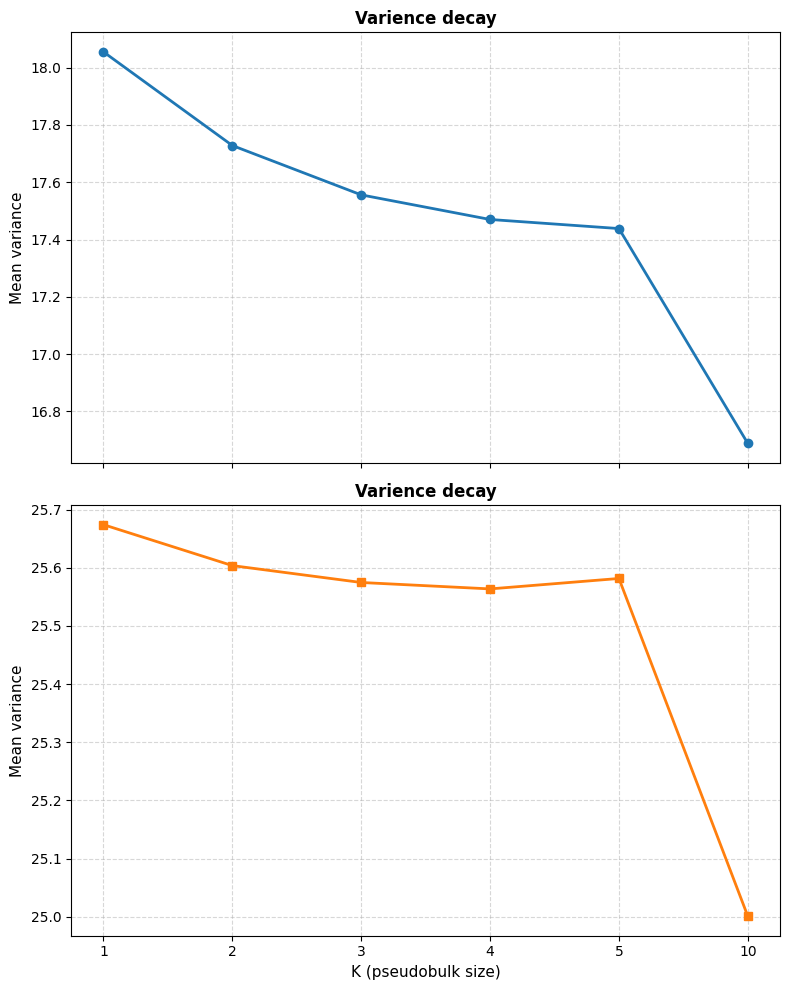

In [86]:
import matplotlib.pyplot as plt
import numpy as np

all_k = [1, 2, 3, 4, 5, 10]
x_indices = list(range(len(all_k)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)



ax1.plot(x_indices, np.log2(rna_vars), marker='o', color='#1f77b4', linewidth=2, label='mRNA')
ax1.set_title('Varience decay', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean variance', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Магия тут: ставим засечки на позиции индексов и переименовываем их в реальные K
ax1.set_xticks(x_indices)
ax1.set_xticklabels([str(k) for k in all_k])

# 2. График для miRNA (нижний)
ax2.plot(x_indices, np.log2(mir_vars), marker='s', color='#ff7f0e', linewidth=2, label='miRNA')
ax2.set_title('Varience decay', fontsize=12, fontweight='bold')
ax2.set_xlabel('K (pseudobulk size)', fontsize=11)
ax2.set_ylabel('Mean variance', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)


ax2.set_xticks(x_indices)
ax2.set_xticklabels([str(k) for k in all_k])

plt.tight_layout()


plt.savefig('variance_decay.pdf', format='pdf', bbox_inches='tight')

plt.show()